In [78]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import bloqade.analog as bqa
!pip install plotly
import plotly.io as pio
pio.renderers.default = 'browser'

    

In [85]:
from math import pi
from bloqade.analog import start

geometry = start.add_position([(0,5), (5,4), (6,9), (12,10), (18,5), (11,6), (12,8)])

hardware_rabi_program = (
  geometry
  .rydberg.rabi.amplitude.uniform
  .piecewise_linear(values = [0, pi/2, pi/2, 0], durations = [0.06, 1.0, 0.06])
)

emulation_results = hardware_rabi_program.bloqade.python().run(100)
bitstring_counts = emulation_results.report().counts()
hardware_rabi_program.show()
print(bitstring_counts)

[OrderedDict({'111110': 15, '011101': 12, '111011': 12, '011011': 11, '101101': 11, '011110': 9, '110101': 9, '110111': 8, '111111': 7, '011111': 3, '101111': 2, '111101': 1})]


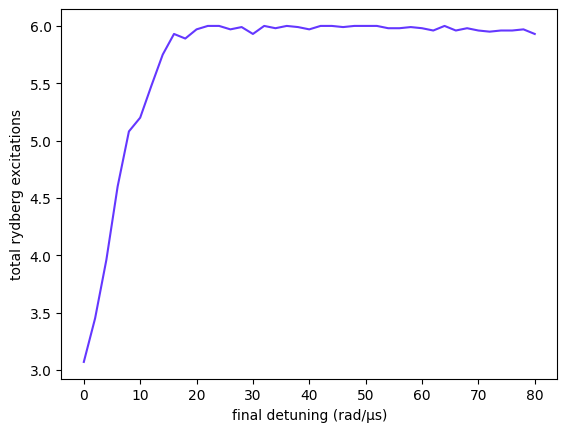

In [ ]:
import os

import numpy as np
import matplotlib.pyplot as plt
from bloqade.analog import load, save
from bloqade.analog import start


if not os.path.isdir("data"):
    os.mkdir("data")

rng = np.random.default_rng(1234)

durations = [0.3, 1.6, 0.3]

geometry = start.add_position([
    (0, 0),
    (20, 0),
    (0, 20),
    (20, 20),
    (10, 30),
    (30, 10)
])

mis_udg_program = (
    geometry
    .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, [0.0, 15.0, 15.0, 0.0])
    .detuning.uniform.piecewise_linear(
        durations, [-30, -30, "final_detuning", "final_detuning"]
    )
)

mis_udg_job = mis_udg_program.batch_assign(final_detuning=np.linspace(0, 80, 41))

filename = os.path.join(os.path.abspath(""), "data", "MIS-UDG-job.json")

if os.path.isfile(filename):
    os.remove(filename)


emulation_results = mis_udg_job.bloqade.python().run(shots=100)
save(emulation_results, filename)

batch = load(filename)
# batch.fetch()
# save(filename, batch)


report = batch.report()

average_rydberg_excitation = report.rydberg_densities(filter_perfect_filling=False).sum(
    axis=1
)
final_detunings = report.list_param("final_detuning")

plt.plot(final_detunings, average_rydberg_excitation, color="#6437FF")
plt.xlabel("final detuning (rad/µs)")
plt.ylabel("total rydberg excitations")
plt.show()

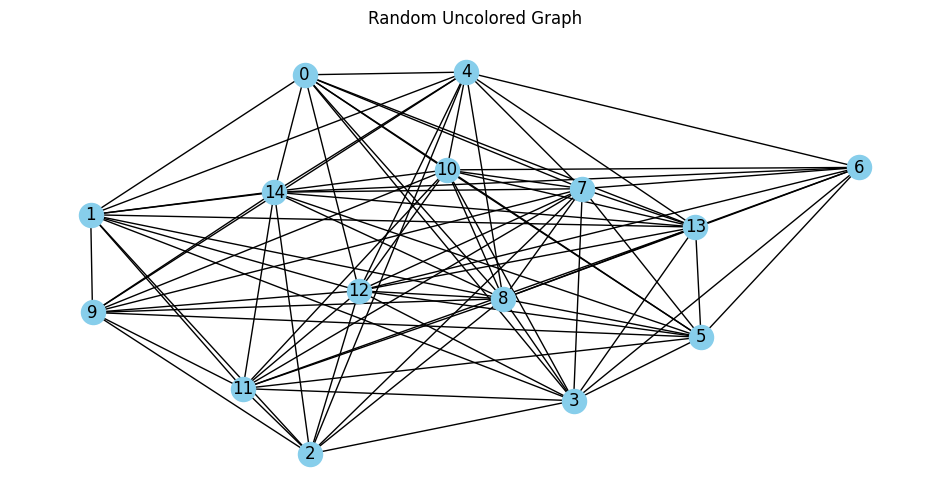

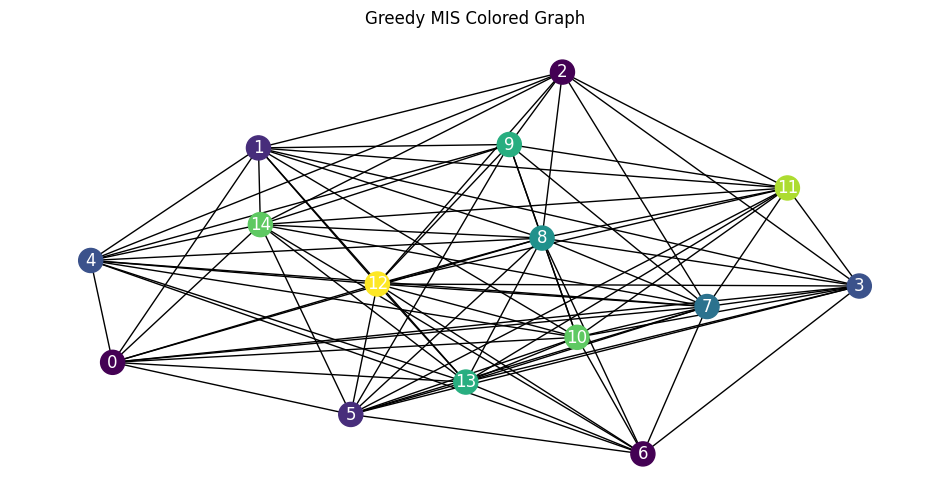

Node Coloring: {0: 0, 2: 0, 6: 0, 1: 1, 5: 1, 3: 2, 4: 2, 7: 3, 8: 4, 9: 5, 13: 5, 10: 6, 14: 6, 11: 7, 12: 8}


In [25]:
import networkx as nx
import random
import matplotlib.pyplot as plt

def generate_random_connected_graph(n, p=0.8):
    """
    Generates a random undirected connected graph with n nodes.

    Args:
        n: The number of nodes in the graph.
        p: The probability of an edge existing between two nodes.  Defaults to 0.5

    Returns:
        A NetworkX Graph object.

    Raises:
        ValueError: If n is less than or equal to 0.
    """
    if n <= 0:
        raise ValueError("Number of nodes must be positive.")

    # Start with an empty graph
    graph = nx.Graph()
    # Add all nodes
    graph.add_nodes_from(range(n))

    # Add edges randomly
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < p:
                graph.add_edge(i, j)

    # Ensure the graph is connected.  If not, add a random edge.
    if not nx.is_connected(graph):
        edges_to_add = []
        for component in nx.connected_components(graph):
            if len(component) > 1:
                nodes_in_component = list(component)
                #connect each component to the first node
                for node in nodes_in_component[1:]:
                  edges_to_add.append((nodes_in_component[0], node))
        graph.add_edges_from(edges_to_add)
        if not nx.is_connected(graph): # Double check
            print("Graph is still not connected after adding edges") # Print statement

    return graph


def greedy_mis_coloring(graph):
    """
    Performs a greedy graph coloring on the given graph.  This implementation
    finds a Maximal Independent Set (MIS) and colors it, then repeats.

    Args:
        graph: A NetworkX Graph object.

    Returns:
        A dictionary where keys are node indices and values are colors (integers
        starting from 0).
    """
    coloring = {}
    nodes = list(graph.nodes())
    available_colors = 0

    while nodes:
        # Find an MIS
        independent_set = []
        remaining_nodes = set(nodes)

        first_node = remaining_nodes.pop()
        independent_set.append(first_node)

        while remaining_nodes:
            node = remaining_nodes.pop()
            is_independent = True
            for selected_node in independent_set:
                if graph.has_edge(node, selected_node):
                    is_independent = False
                    break
            if is_independent:
                independent_set.append(node)

        # Color the MIS
        for node in independent_set:
            coloring[node] = available_colors
            if node in nodes: # remove colored nodes.
                nodes.remove(node)
        available_colors += 1
    return coloring



def visualize_graph(graph, layout_func, title, node_colors=None):
    """
    Visualizes the graph with and without coloring.

    Args:
        graph: A NetworkX Graph object.
        layout_func: A NetworkX layout function (e.g., nx.spring_layout).
        title: The title of the plot.
        node_colors: An optional dictionary of node colors. If None, all nodes
            will be plotted in the same default color.
    """
    plt.figure(figsize=(12, 6))
    plt.title(title)

    # Use the specified layout function
    pos = layout_func(graph)

    if node_colors:
        # Extract colors and nodes as lists, handle missing colors
        colors = [node_colors.get(node, 'gray') for node in graph.nodes()]  # 'gray' for uncolored
        nx.draw(graph, pos, with_labels=True, node_color=colors, font_color='white')
    else:
        nx.draw(graph, pos, with_labels=True, node_color='skyblue', font_color='black')

    plt.show()

def main():
    """
    Main function to generate, color, and visualize the graph.
    """
    n = 15  # Number of nodes
    random_graph = generate_random_connected_graph(n)

    # Visualize the uncolored graph
    visualize_graph(random_graph, nx.spring_layout, "Random Uncolored Graph")

    # Color the graph
    node_coloring = greedy_mis_coloring(random_graph)

    # Visualize the colored graph
    visualize_graph(random_graph, nx.spring_layout, "Greedy MIS Colored Graph", node_colors=node_coloring)
    print(f"Node Coloring: {node_coloring}") # Print the node coloring

if __name__ == "__main__":
    main()
